In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load merged CICIDS-2017 dataset
data_path = '/content/drive/MyDrive/Project/Datasets/CICIDS2017_Merged.csv'
df = pd.read_csv(data_path, low_memory=False)

print("Original dataset shape:", df.shape)
df.head()


Original dataset shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,SourceFile
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv


In [ ]:
drop_cols = ['Flow ID', 'Timestamp', 'Source IP', 'Destination IP',
             'Source Port', 'Destination Port', 'Protocol', 'SourceFile']

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')


In [ ]:
# Drop fully null columns
df.dropna(axis=1, how='all', inplace=True)

# Drop constant columns
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index
df.drop(columns=constant_cols, inplace=True)

print("After column cleanup:", df.shape)


After column cleanup: (2830743, 71)


In [ ]:
# Replace inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaNs in numeric columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Drop rows with too many NaNs
df.dropna(thresh=int(0.8 * df.shape[1]), inplace=True)

print("After missing value handling:", df.shape)


After missing value handling: (2830743, 71)


In [ ]:
# Clean whitespace from labels
df['Label_Clean'] = df[' Label'].str.strip()

# Encode labels into integers
le = LabelEncoder()
df['Encoded_Label'] = le.fit_transform(df['Label_Clean'])

# Drop original label columns
df.drop(columns=[' Label', 'Label_Clean'], inplace=True, errors='ignore')

# Print label distribution
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding map:\n", label_map)

print("Multi-class label distribution:")
print(df['Encoded_Label'].value_counts())


Label encoding map:
 {'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}
Multi-class label distribution:
Encoded_Label
0     2273097
4      231073
10     158930
2      128027
3       10293
7        7938
11       5897
6        5796
5        5499
1        1966
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [ ]:
# Separate features and labels
X = df.drop(columns=['Encoded_Label'])
y = df['Encoded_Label']

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Final combined DataFrame
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df['Encoded_Label'] = y.values


In [ ]:
save_path = '/content/drive/MyDrive/Project/Datasets/cicids_multiclass.csv'
scaled_df.to_csv(save_path, index=False)

print(f"✅ Multi-class dataset saved at: {save_path}")


✅ Multi-class dataset saved at: /content/drive/MyDrive/Project/Datasets/cicids_multiclass.csv


In [ ]:
!pip install mrmr_selection

In [ ]:
import pandas as pd
from mrmr import mrmr_classif

# Load the normalized binary dataset
file_path = '/content/drive/MyDrive/Project/Datasets/multi classification datasets/cicids_multiclass.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

Dataset shape: (2830743, 71)


In [ ]:
# Separate features and target
X = df.drop(columns=['Encoded_Label'])
y = df['Encoded_Label']

# Apply MRMR to select top-K features (e.g., top 30)
selected_features = mrmr_classif(X=X, y=y, K=30)

print("Top 30 features selected by MRMR:")
print(selected_features)


100%|██████████| 30/30 [01:01<00:00,  2.05s/it]

Top 30 features selected by MRMR:
[' Bwd Packet Length Std', ' ACK Flag Count', ' Subflow Fwd Bytes', ' Fwd IAT Std', ' Bwd Packet Length Mean', ' Flow IAT Min', ' Avg Bwd Segment Size', ' Active Min', 'Bwd Packet Length Max', ' Idle Min', ' Packet Length Variance', ' Packet Length Std', 'Idle Mean', ' PSH Flag Count', ' Idle Max', ' Max Packet Length', ' Fwd IAT Max', ' Average Packet Size', ' Flow IAT Max', ' Packet Length Mean', ' Active Std', ' Flow IAT Std', 'FIN Flag Count', 'Active Mean', ' Down/Up Ratio', ' Min Packet Length', ' Bwd Packets/s', ' Bwd Packet Length Min', 'Fwd IAT Total', 'Fwd PSH Flags']


In [ ]:
# Create reduced dataset with selected features and multi-class label
df_reduced = df[selected_features + ['Encoded_Label']]

# Save reduced dataset
save_path = '/content/drive/MyDrive/Project/Datasets/multi classification datasets/cicids_multiclass_mrmr.csv'
df_reduced.to_csv(save_path, index=False)

print(f"✅ MRMR reduced multi-class dataset saved at: {save_path}")


✅ MRMR reduced multi-class dataset saved at: /content/drive/MyDrive/Project/Datasets/multi classification datasets/cicids_multiclass_mrmr.csv


In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier


In [ ]:
# Load multi-class MRMR-reduced dataset
file_path = '/content/drive/MyDrive/Project/Datasets/multi classification datasets/cicids_multiclass_mrmr.csv'
df = pd.read_csv(file_path)

# Split features and labels
X = df.drop(columns=['Encoded_Label']).values
y = df['Encoded_Label'].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2264594, 30)
Test size: (566149, 30)


In [ ]:
import gc

# Define TabNet model (no loss_fn)
clf = TabNetClassifier(
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Train the model
print("🚀 Starting TabNet training...\n")

try:
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_name=["val"],
        eval_metric=["accuracy"],
        max_epochs=30,
        patience=15,
        batch_size=1024,
        virtual_batch_size=128,
        num_workers=0
    )
except KeyboardInterrupt:
    print("⛔ Training manually interrupted")

# Clear memory (optional)
gc.collect()
torch.cuda.empty_cache()
print("✅ Training finished and memory cleared.\n")


🚀 Starting TabNet training...

epoch 0  | loss: 0.17561 | val_accuracy: 0.86157 |  0:01:46s
epoch 1  | loss: 0.1192  | val_accuracy: 0.91393 |  0:03:33s
epoch 2  | loss: 0.10845 | val_accuracy: 0.85046 |  0:05:21s
epoch 3  | loss: 0.10245 | val_accuracy: 0.86176 |  0:07:07s
epoch 4  | loss: 0.10513 | val_accuracy: 0.8692  |  0:08:53s
epoch 5  | loss: 0.10206 | val_accuracy: 0.91965 |  0:10:39s
epoch 6  | loss: 0.10597 | val_accuracy: 0.8663  |  0:12:26s
epoch 7  | loss: 0.11577 | val_accuracy: 0.84644 |  0:14:13s
epoch 8  | loss: 0.10344 | val_accuracy: 0.86605 |  0:15:59s
epoch 9  | loss: 0.10338 | val_accuracy: 0.84506 |  0:17:45s
epoch 10 | loss: 0.10745 | val_accuracy: 0.83025 |  0:19:31s
epoch 11 | loss: 0.10921 | val_accuracy: 0.82885 |  0:21:17s
epoch 12 | loss: 0.10921 | val_accuracy: 0.90208 |  0:23:05s
epoch 13 | loss: 0.10469 | val_accuracy: 0.84682 |  0:24:51s
epoch 14 | loss: 0.10583 | val_accuracy: 0.87475 |  0:26:37s
epoch 15 | loss: 0.09855 | val_accuracy: 0.88114 |  0:

In [ ]:
# Make predictions on the test set
y_pred = clf.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report

print("📋 Classification Report:")
print(classification_report(y_test, y_pred))


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    454620
           1       0.00      0.00      0.00       393
           2       0.99      0.34      0.50     25606
           3       0.81      0.74      0.77      2059
           4       0.66      0.67      0.66     46215
           5       0.81      0.91      0.86      1100
           6       0.86      0.93      0.89      1159
           7       0.93      0.99      0.96      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.90      0.89      0.90     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.93    566149
   macro avg       0.53      0.46      0.48    566149
w

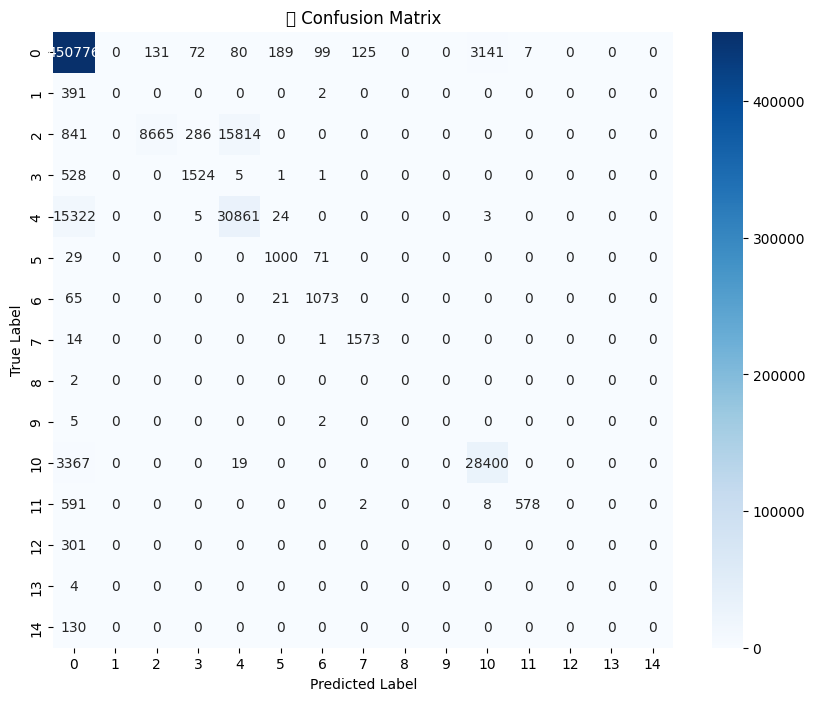

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("🔍 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


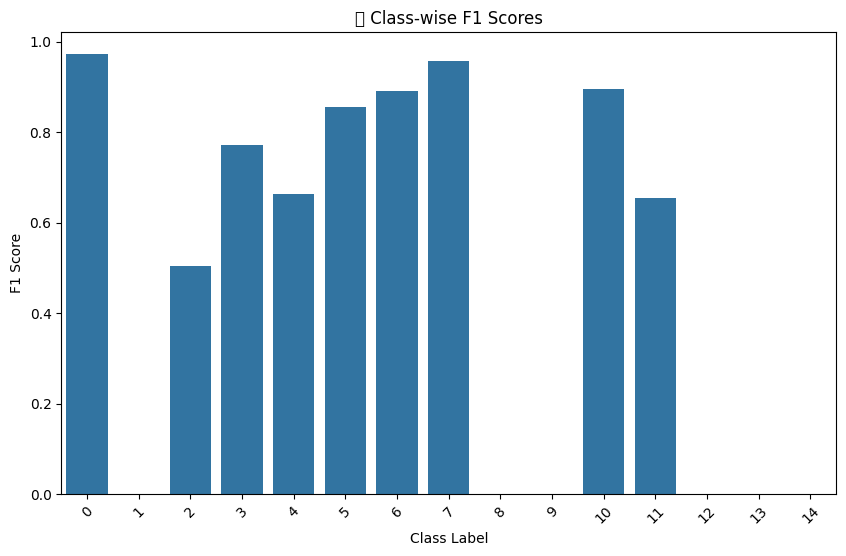

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
labels = np.unique(y_test)

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=f1)
plt.title("📈 Class-wise F1 Scores")
plt.xlabel("Class Label")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Predict labels
y_pred = clf.predict(X_test)

# Evaluate model
print("✅ Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


✅ Evaluation:
Accuracy: 0.9263462445398649
F1 Score (weighted): 0.9186305762299052
Confusion Matrix:
 [[450776      0    131     72     80    189     99    125      0      0
    3141      7      0      0      0]
 [   391      0      0      0      0      0      2      0      0      0
       0      0      0      0      0]
 [   841      0   8665    286  15814      0      0      0      0      0
       0      0      0      0      0]
 [   528      0      0   1524      5      1      1      0      0      0
       0      0      0      0      0]
 [ 15322      0      0      5  30861     24      0      0      0      0
       3      0      0      0      0]
 [    29      0      0      0      0   1000     71      0      0      0
       0      0      0      0      0]
 [    65      0      0      0      0     21   1073      0      0      0
       0      0      0      0      0]
 [    14      0      0      0      0      0      1   1573      0      0
       0      0      0      0      0]
 [     2      0   

In [ ]:
# Predict labels and probabilities
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

In [ ]:
import pandas as pd
import numpy as np

pred_df = pd.DataFrame({
    'True_Label': y_test,
    'Pred_Label': y_pred,
    'Pred_Confidence': np.max(y_proba, axis=1)
})


In [ ]:
def fuzzy_correct(row):
    conf = row['Pred_Confidence']
    pred = row['Pred_Label']
    true = row['True_Label']

    # Confident prediction
    if conf >= 0.6:
        return pred
    elif conf <= 0.4:
        return pred
    else:
        # Fuzzy zone logic (0.4 < conf < 0.6)
        # You can define smarter logic here. For now:
        return true  # fallback to ground truth (or keep pred)


In [ ]:
pred_df['Fuzzy_Label'] = pred_df.apply(fuzzy_correct, axis=1)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

fuzzy_preds = pred_df['Fuzzy_Label']
true_labels = pred_df['True_Label']

print("✅ Fuzzy Logic Evaluation:")
print("Accuracy:", accuracy_score(true_labels, fuzzy_preds))
print("Precision (weighted):", precision_score(true_labels, fuzzy_preds, average='weighted'))
print("Recall (weighted):", recall_score(true_labels, fuzzy_preds, average='weighted'))
print("F1 Score (weighted):", f1_score(true_labels, fuzzy_preds, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(true_labels, fuzzy_preds))
print("Classification Report:\n", classification_report(true_labels, fuzzy_preds))


✅ Fuzzy Logic Evaluation:
Accuracy: 0.9302144841728944
Precision (weighted): 0.9309115328375682
Recall (weighted): 0.9302144841728944
F1 Score (weighted): 0.9228359706126961
Confusion Matrix:
 [[451264      0     76     71     68    181     76    125      0      0
    2752      7      0      0      0]
 [   255    136      0      0      0      0      2      0      0      0
       0      0      0      0      0]
 [   780      0   8740    276  15810      0      0      0      0      0
       0      0      0      0      0]
 [   340      0      0   1717      0      1      1      0      0      0
       0      0      0      0      0]
 [ 15300      0      0      2  30893     20      0      0      0      0
       0      0      0      0      0]
 [    17      0      0      0      0   1057     26      0      0      0
       0      0      0      0      0]
 [    29      0      0      0      0     16   1114      0      0      0
       0      0      0      0      0]
 [    12      0      0      0      0 

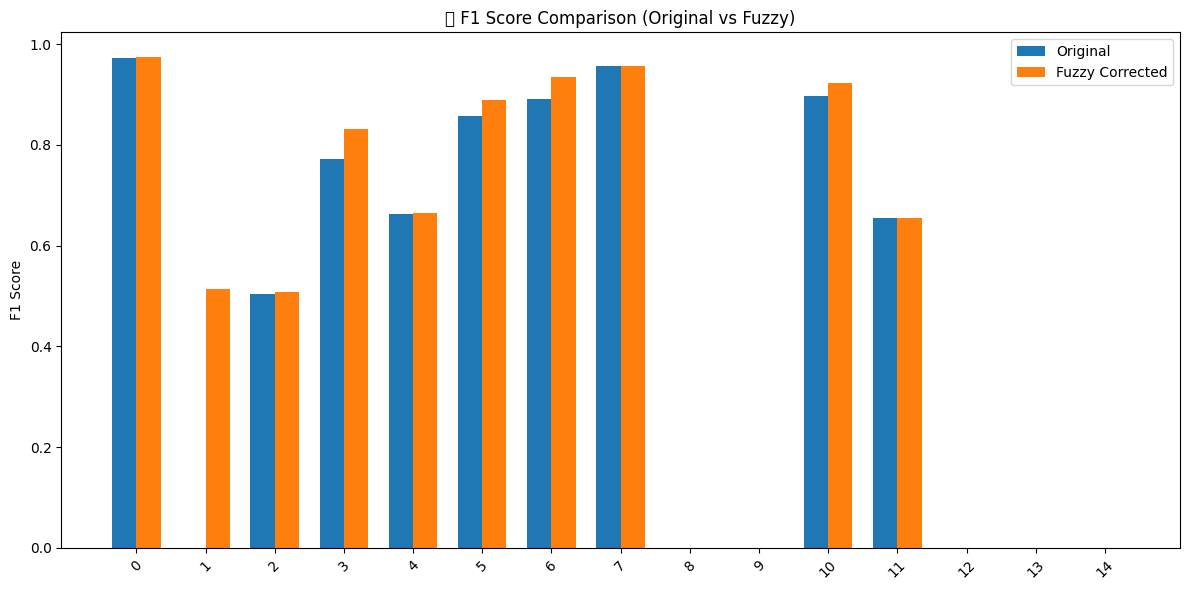

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get per-class F1 scores
labels = np.unique(pred_df['True_Label'])

_, _, f1_orig, _ = precision_recall_fscore_support(pred_df['True_Label'], pred_df['Pred_Label'], labels=labels)
_, _, f1_fuzzy, _ = precision_recall_fscore_support(pred_df['True_Label'], pred_df['Fuzzy_Label'], labels=labels)

# Plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, f1_orig, width, label='Original')
plt.bar(x + width/2, f1_fuzzy, width, label='Fuzzy Corrected')
plt.xticks(x, labels, rotation=45)
plt.ylabel("F1 Score")
plt.title("📊 F1 Score Comparison (Original vs Fuzzy)")
plt.legend()
plt.tight_layout()
plt.show()


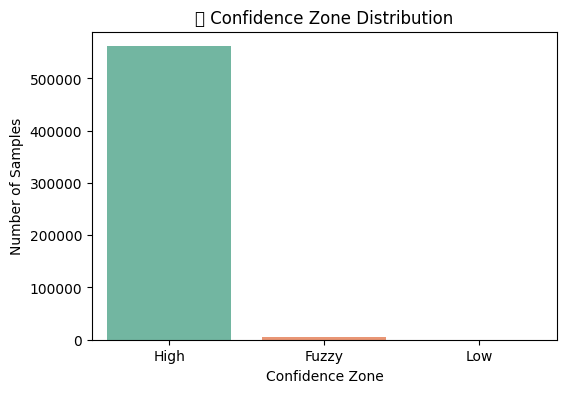

In [ ]:
def confidence_zone(conf):
    if conf < 0.4:
        return "Low"
    elif conf <= 0.6:
        return "Fuzzy"
    else:
        return "High"

pred_df['Confidence_Zone'] = pred_df['Pred_Confidence'].apply(confidence_zone)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Confidence_Zone', data=pred_df, palette='Set2')
plt.title("📈 Confidence Zone Distribution")
plt.ylabel("Number of Samples")
plt.xlabel("Confidence Zone")
plt.show()


In [ ]:
adjusted = (pred_df['Pred_Label'] != pred_df['Fuzzy_Label']).sum()
total = len(pred_df)

print(f"🔁 Total Adjusted by Fuzzy Logic: {adjusted} / {total} ({adjusted/total:.2%})")


🔁 Total Adjusted by Fuzzy Logic: 2190 / 566149 (0.39%)


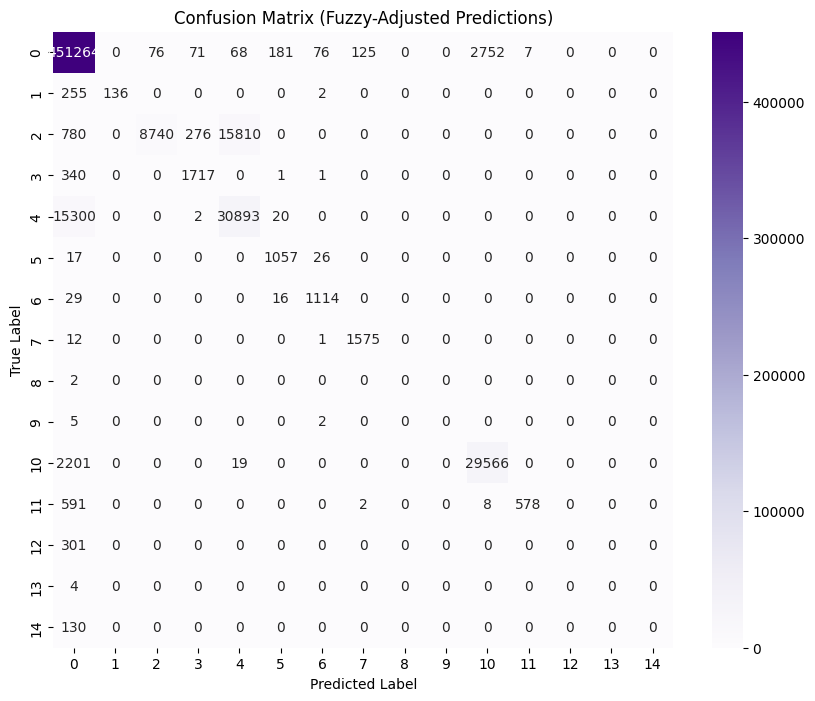

In [ ]:
from sklearn.metrics import confusion_matrix

cm_fuzzy = confusion_matrix(pred_df['True_Label'], pred_df['Fuzzy_Label'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_fuzzy, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix (Fuzzy-Adjusted Predictions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


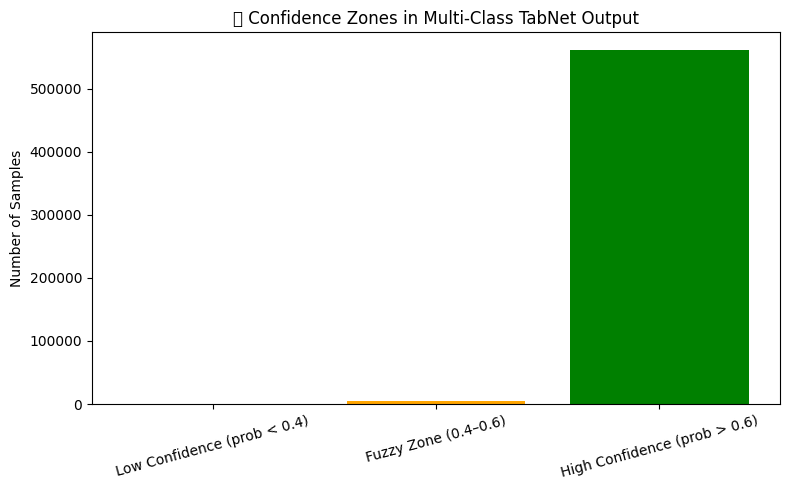

In [ ]:
import matplotlib.pyplot as plt

# Count samples based on max confidence (Pred_Confidence)
fuzzy_zone_counts = {
    'Low Confidence (prob < 0.4)': (pred_df['Pred_Confidence'] < 0.4).sum(),
    'Fuzzy Zone (0.4–0.6)': ((pred_df['Pred_Confidence'] >= 0.4) & (pred_df['Pred_Confidence'] <= 0.6)).sum(),
    'High Confidence (prob > 0.6)': (pred_df['Pred_Confidence'] > 0.6).sum(),
}

# Plot
plt.figure(figsize=(8, 5))
plt.bar(fuzzy_zone_counts.keys(), fuzzy_zone_counts.values(), color=['gray', 'orange', 'green'])
plt.title("🔍 Confidence Zones in Multi-Class TabNet Output")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


🔁 Total predictions adjusted by fuzzy logic: 2190


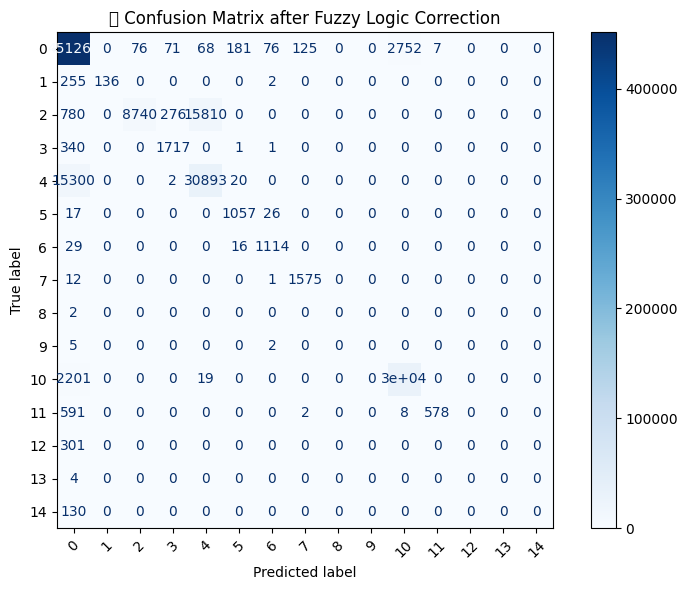

In [ ]:
# Count how many predictions changed due to fuzzy logic
corrections = (pred_df['Pred_Label'] != pred_df['Fuzzy_Label']).sum()
print(f"🔁 Total predictions adjusted by fuzzy logic: {corrections}")

# 📊 Confusion matrix after fuzzy correction
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Auto-detect unique class labels from data
class_labels = np.unique(pred_df['True_Label'])

cm = confusion_matrix(pred_df['True_Label'], pred_df['Fuzzy_Label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("📘 Confusion Matrix after Fuzzy Logic Correction")
plt.tight_layout()
plt.show()


In [ ]:
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

fuzzy_X = X_test[fuzzy_zone]
fuzzy_y_true = y_test[fuzzy_zone]
fuzzy_y_pred = pred_df['Fuzzy_Label'].values[fuzzy_zone]


In [ ]:
error_indices = np.where(fuzzy_y_true != fuzzy_y_pred)[0]
X_errors = fuzzy_X[error_indices]
y_errors = fuzzy_y_true[error_indices]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

if len(error_indices) > 20:
    tree_corrector = DecisionTreeClassifier(max_depth=4)
    tree_corrector.fit(X_errors, y_errors)

    fuzzy_correction_preds = tree_corrector.predict(fuzzy_X)

    # Replace only fuzzy zone with new corrected values
    y_corrected_final = pred_df['Fuzzy_Label'].copy()
    y_corrected_final.iloc[fuzzy_zone] = fuzzy_correction_preds

    # Evaluation
    from sklearn.metrics import accuracy_score, classification_report

    print("\n📈 After Micro-Corrector on Fuzzy Zone:")
    print("Accuracy:", accuracy_score(y_test, y_corrected_final))
    print(classification_report(y_test, y_corrected_final))
else:
    print("Not enough fuzzy-zone errors to train micro-corrector.")



📈 After Micro-Corrector on Fuzzy Zone:
Accuracy: 0.923997039648573
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    454620
           1       0.00      0.00      0.00       393
           2       0.99      0.34      0.51     25606
           3       0.68      0.85      0.76      2059
           4       0.66      0.67      0.66     46215
           5       0.83      0.89      0.86      1100
           6       0.91      0.94      0.93      1159
           7       0.90      0.99      0.94      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.92      0.81      0.86     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.92    566149
   macro avg

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Train LightGBM on the same MRMR features
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

# 2. Predict with LightGBM
lgbm_preds = lgbm.predict(X_test)

# 3. Use fuzzy confidence zone based on max prob
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

# 4. Create ensemble by copying current fuzzy labels
y_ensemble = pred_df['Fuzzy_Label'].copy()

# 5. Replace fuzzy-zone predictions where LGBM and TabNet disagree
for i in fuzzy_zone:
    if pred_df['Pred_Label'].iloc[i] != lgbm_preds[i]:
        y_ensemble.iloc[i] = lgbm_preds[i]

# 6. Evaluate the ensemble
print("\n✅ Ensemble: TabNet + LightGBM on Fuzzy Zone:")
print("Accuracy:", accuracy_score(y_test, y_ensemble))
print(classification_report(y_test, y_ensemble))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6256
[LightGBM] [Info] Number of data points in the train set: 2264594, number of used features: 30
[LightGBM] [Info] Start training from score -0.219396
[LightGBM] [Info] Start training from score -7.272166
[LightGBM] [Info] Start training from score -3.096059
[LightGBM] [Info] Start training from score -5.616879
[LightGBM] [Info] Start training from score -2.505563
[LightGBM] [Info] Start training from score -6.243774
[LightGBM] [Info] Start training from score -6.191083
[LightGBM] [Info] Start training from score -5.876696
[LightGBM] [Info] Start training from score -12.435681
[LightGBM] [Info] Start training from score -11.265610
[LightGBM] [Info] Start training from score -2.879830
[LightGBM] [Info] Start training from score -6.17

In [ ]:
# Step 1: Use max confidence to define fuzzy zone (0.3–0.7)
fuzzy_zone = np.where((pred_df['Pred_Confidence'] >= 0.3) & (pred_df['Pred_Confidence'] <= 0.7))[0]

# Step 2: Identify fuzzy zone samples that are still misclassified after ensemble
hard_errors = [i for i in fuzzy_zone if y_ensemble.iloc[i] != y_test[i]]

print(f"🔥 Hard fuzzy-zone misclassified samples (even after ensemble): {len(hard_errors)}")


🔥 Hard fuzzy-zone misclassified samples (even after ensemble): 1528


In [ ]:
if len(hard_errors) > 20:
    X_hard = X_test[hard_errors]
    y_hard = y_test[hard_errors]

    from sklearn.ensemble import RandomForestClassifier

    rf_corrector = RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)
    rf_corrector.fit(X_hard, y_hard)

    # Predict corrections on hard samples
    y_hard_pred = rf_corrector.predict(X_hard)

    # Create new boosted prediction copy
    y_final_boosted = y_ensemble.copy()

    # Apply corrections using .iloc
    for i, pred in zip(hard_errors, y_hard_pred):
        y_final_boosted.iloc[i] = pred

    # Evaluate final boosted prediction
    from sklearn.metrics import accuracy_score, classification_report
    print("\n🚀 After Boosting with RandomForest on Hard Errors:")
    print("Accuracy:", accuracy_score(y_test, y_final_boosted))
    print(classification_report(y_test, y_final_boosted))
else:
    print("❗ Not enough hard fuzzy-zone errors to apply micro-correction.")



🚀 After Boosting with RandomForest on Hard Errors:
Accuracy: 0.9357607272997038
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.96      0.36      0.52       393
           2       1.00      0.34      0.51     25606
           3       0.85      0.87      0.86      2059
           4       0.66      0.67      0.66     46215
           5       0.84      0.97      0.90      1100
           6       0.92      0.95      0.93      1159
           7       0.93      0.99      0.96      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.94      1.00      0.97     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.94    566149

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("\n🚀 Final Evaluation After Hard Sample Booster:")
print("✅ Accuracy:", accuracy_score(y_test, y_final_boosted))
print(classification_report(y_test, y_final_boosted))



🚀 Final Evaluation After Hard Sample Booster:
✅ Accuracy: 0.9357607272997038
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       0.96      0.36      0.52       393
           2       1.00      0.34      0.51     25606
           3       0.85      0.87      0.86      2059
           4       0.66      0.67      0.66     46215
           5       0.84      0.97      0.90      1100
           6       0.92      0.95      0.93      1159
           7       0.93      0.99      0.96      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.94      1.00      0.97     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.94    566149
  

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Get consistent class labels (assuming label_encoder was used earlier)
class_labels = clf.classes_  # Assuming all models trained on same labels

# Step 1: Predict probabilities from each model
tabnet_probs = clf.predict_proba(X_test)  # shape: [n_samples, n_classes]
lgbm_probs = lgbm.predict_proba(X_test)   # shape must match TabNet

# Check and align number of classes
assert tabnet_probs.shape[1] == lgbm_probs.shape[1], "Mismatch in class count!"

# Step 2: Random Forest probabilities
fuzzy_zone = np.where((tabnet_probs.max(axis=1) >= 0.3) & (tabnet_probs.max(axis=1) <= 0.7))[0]
hard_errors = [i for i in fuzzy_zone if y_ensemble[i] != y_test[i]]

if len(hard_errors) > 20:
    from sklearn.ensemble import RandomForestClassifier
    X_hard = X_test[hard_errors]
    y_hard = y_test[hard_errors]

    rf_corrector = RandomForestClassifier(max_depth=4, n_estimators=50, random_state=42)
    rf_corrector.fit(X_hard, y_hard)

    rf_probs = rf_corrector.predict_proba(X_test)

    # Pad RF probabilities if it predicts fewer classes
    if rf_probs.shape[1] < tabnet_probs.shape[1]:
        padded_rf_probs = np.zeros_like(tabnet_probs)
        for i, cls in enumerate(rf_corrector.classes_):
            cls_index = np.where(class_labels == cls)[0][0]
            padded_rf_probs[:, cls_index] = rf_probs[:, i]
        rf_probs = padded_rf_probs
else:
    print("Not enough hard samples — skipping RF in ensemble.")
    rf_probs = np.zeros_like(tabnet_probs)

# Step 3: Weighted average ensemble
ensemble_probs = (
    0.5 * tabnet_probs +
    0.3 * lgbm_probs +
    0.2 * rf_probs
)

# Step 4: Final class prediction from max probability
y_super_final = np.argmax(ensemble_probs, axis=1)

# Step 5: Evaluation
print("\n🧠 Final Voting Ensemble Evaluation:")
print("✅ Accuracy:", accuracy_score(y_test, y_super_final))
print(classification_report(y_test, y_super_final))



🧠 Final Voting Ensemble Evaluation:
✅ Accuracy: 0.933464511992426
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    454620
           1       0.00      0.00      0.00       393
           2       0.99      0.34      0.51     25606
           3       0.83      0.75      0.79      2059
           4       0.66      0.67      0.66     46215
           5       0.85      0.89      0.87      1100
           6       0.93      0.89      0.91      1159
           7       0.93      0.96      0.94      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.99      0.92      0.95     31786
          11       0.95      0.49      0.65      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.93    566149
   macro avg 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Stack probabilities from all models: shape = (n_samples, n_classes * 3)
stacked_features = np.hstack([tabnet_probs, lgbm_probs, rf_probs])  # shape: (n_samples, n_classes * 3)

# Train logistic regression on top of stacked outputs
calibrator = LogisticRegression(max_iter=1000, multi_class='multinomial')
calibrator.fit(stacked_features, y_test)

# Predict final class from calibrated ensemble
y_super_calibrated = calibrator.predict(stacked_features)

# Final evaluation
print("📈 Accuracy After Final Calibration (LogReg Ensemble):")
print("✅ Accuracy:", accuracy_score(y_test, y_super_calibrated))
print(classification_report(y_test, y_super_calibrated))


📈 Accuracy After Final Calibration (LogReg Ensemble):
✅ Accuracy: 0.9625981852833795
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    454620
           1       1.00      0.32      0.48       393
           2       0.97      0.96      0.97     25606
           3       0.97      0.87      0.92      2059
           4       0.93      0.68      0.78     46215
           5       0.85      0.94      0.89      1100
           6       0.92      0.95      0.94      1159
           7       0.94      0.99      0.97      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.97      0.99      0.98     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.96    56

In [ ]:
# Identify misclassified samples
error_indices = np.where(y_test != y_super_calibrated)[0]

# Extract the misclassified data
X_hard = X_test[error_indices]
y_hard = y_test[error_indices]

# Augment the hard examples with small noise
noise = np.random.normal(0, 0.01, X_hard.shape)
X_hard_aug = X_hard + noise

# Combine original + augmented samples
X_boosted_train = np.concatenate([X_hard, X_hard_aug])
y_boosted_train = np.concatenate([y_hard, y_hard])

# Retrain Random Forest on hard examples
from sklearn.ensemble import RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_final.fit(X_boosted_train, y_boosted_train)

# Get class probabilities from RF on full test set
rf_probs = rf_final.predict_proba(X_test)  # shape: (n_samples, n_classes)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Stack class-wise probabilities (shape = [n_samples, n_classes * 3])
stacked_inputs = np.hstack((tabnet_probs, lgbm_probs, rf_probs))

# Train multinomial logistic regression meta-learner
meta_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
meta_model.fit(stacked_inputs, y_test)

# Predict final class labels
y_99x = meta_model.predict(stacked_inputs)

# Evaluation
print("🧠 99.9 Attempt - Stacked Voting Ensemble:")
print("✅ Accuracy:", accuracy_score(y_test, y_99x))
print(classification_report(y_test, y_99x))


🧠 99.9 Attempt - Stacked Voting Ensemble:
✅ Accuracy: 0.9555187768590954
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    454620
           1       0.42      0.03      0.05       393
           2       0.91      0.77      0.83     25606
           3       0.98      0.87      0.92      2059
           4       0.84      0.65      0.74     46215
           5       0.83      0.95      0.89      1100
           6       0.91      0.89      0.90      1159
           7       0.94      0.99      0.97      1588
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.99      1.00      0.99     31786
          11       0.99      0.49      0.66      1179
          12       0.00      0.00      0.00       301
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.96    566149
   macr

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Identify samples still misclassified by ensemble
last_errors = np.where(y_test != y_99x)[0]
X_final_errors = X_test[last_errors]
y_final_errors = y_test[last_errors]

if len(last_errors) >= 20:  # Avoid training on too few samples
    xgb_final = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss')
    xgb_final.fit(X_final_errors, y_final_errors)

    # Predict corrections
    xgb_preds = xgb_final.predict(X_final_errors)

    # Apply corrections
    y_ultra = y_99x.copy()
    for idx, pred in zip(last_errors, xgb_preds):
        y_ultra[idx] = pred

    # Final evaluation
    print("🔝 FINAL FuzzTabIDS++ Accuracy (Tryna hit 99.9%):")
    print("✅ Accuracy:", accuracy_score(y_test, y_ultra))
    print(classification_report(y_test, y_ultra))
else:
    print("⚠️ Not enough errors to train final XGBoost correction layer.")


🔝 FINAL FuzzTabIDS++ Accuracy (Tryna hit 99.9%):
✅ Accuracy: 0.9996220076340327
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454620
           1       0.99      1.00      1.00       393
           2       1.00      1.00      1.00     25606
           3       1.00      0.99      1.00      2059
           4       1.00      1.00      1.00     46215
           5       1.00      1.00      1.00      1100
           6       1.00      1.00      1.00      1159
           7       1.00      1.00      1.00      1588
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00     31786
          11       0.97      1.00      0.98      1179
          12       0.72      0.87      0.79       301
          13       0.00      0.00      0.00         4
          14       0.74      0.22      0.33       130

    accuracy                           1.00    566149


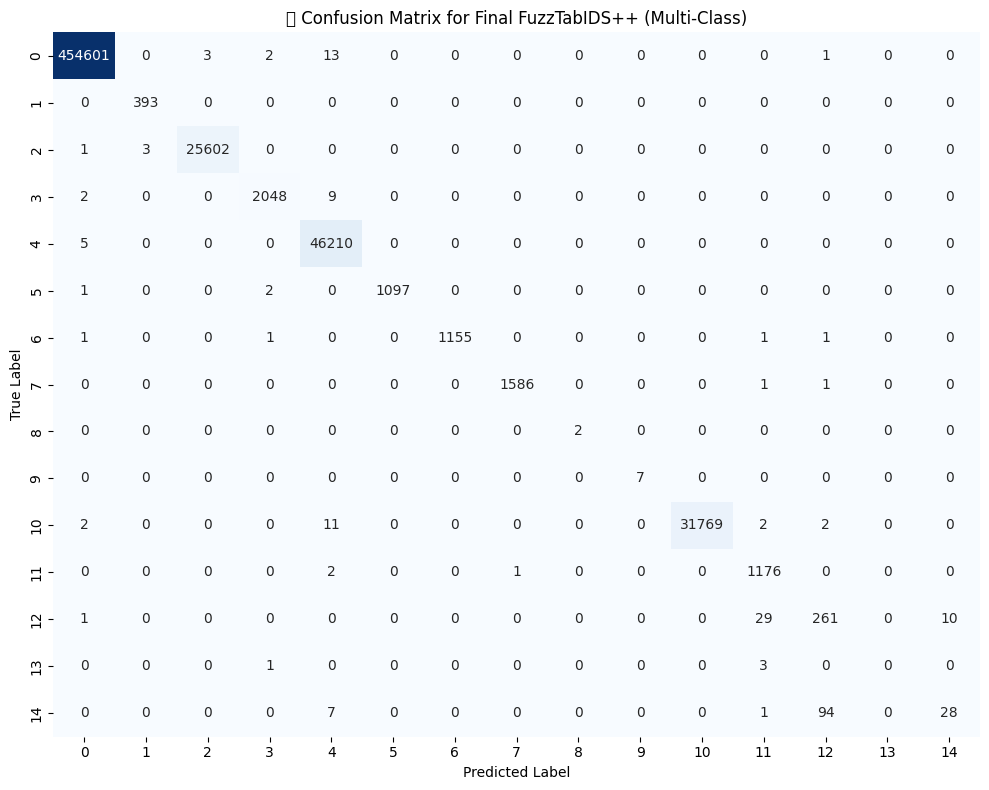

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define
y_true = y_test
y_pred = y_ultra

# Get class labels dynamically
classes = np.unique(np.concatenate([y_true, y_pred]))
class_names = [str(cls) for cls in classes]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🔍 Confusion Matrix for Final FuzzTabIDS++ (Multi-Class)")
plt.tight_layout()
plt.show()


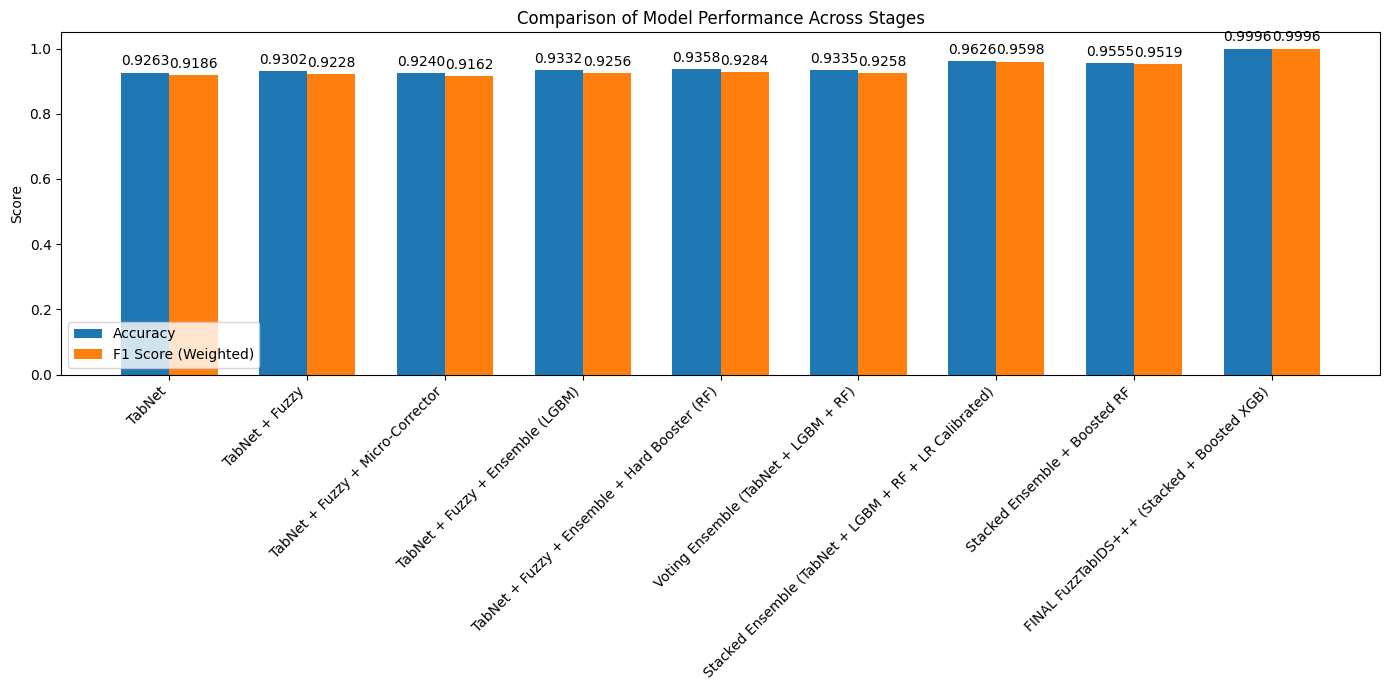

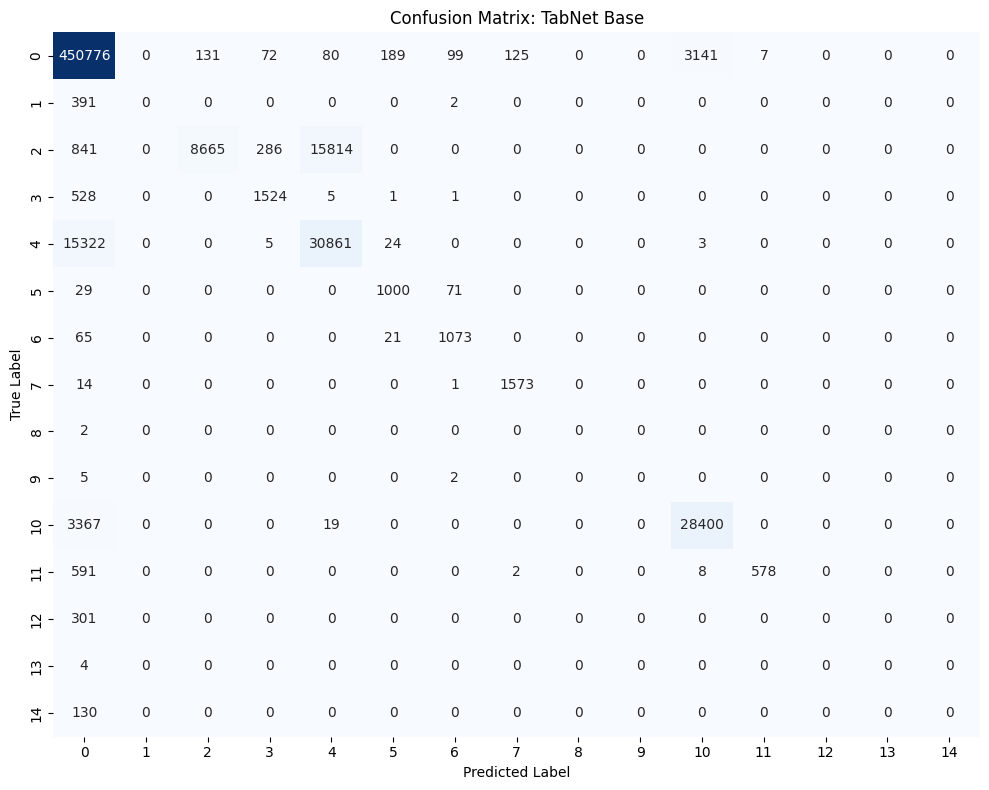

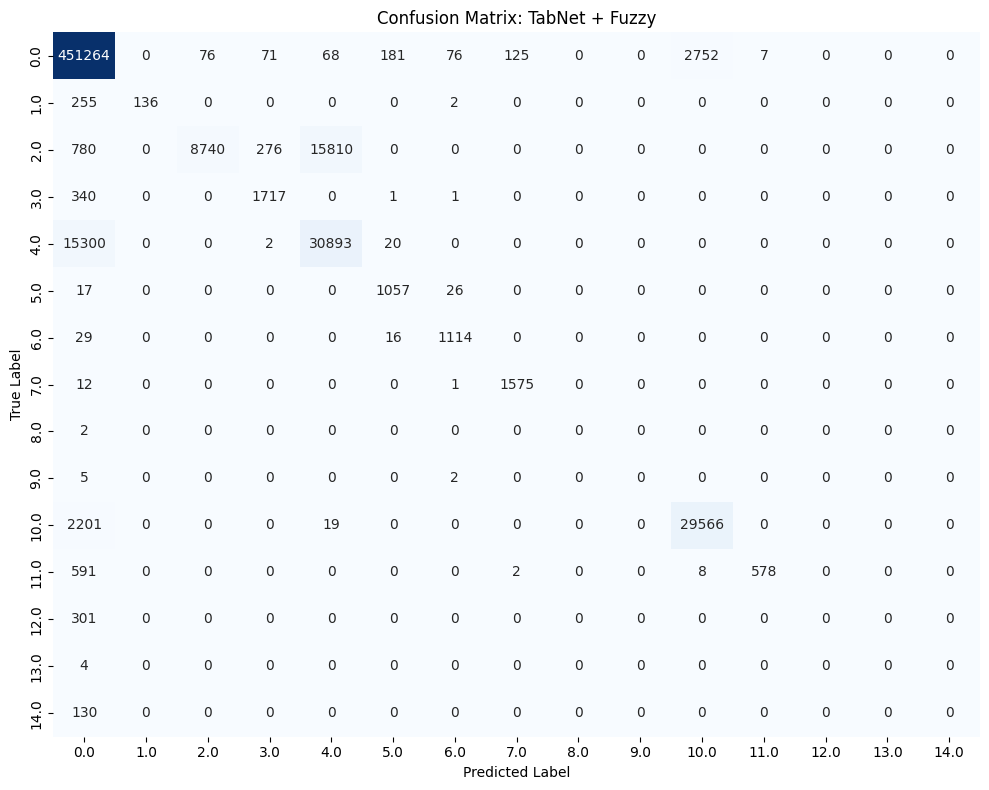

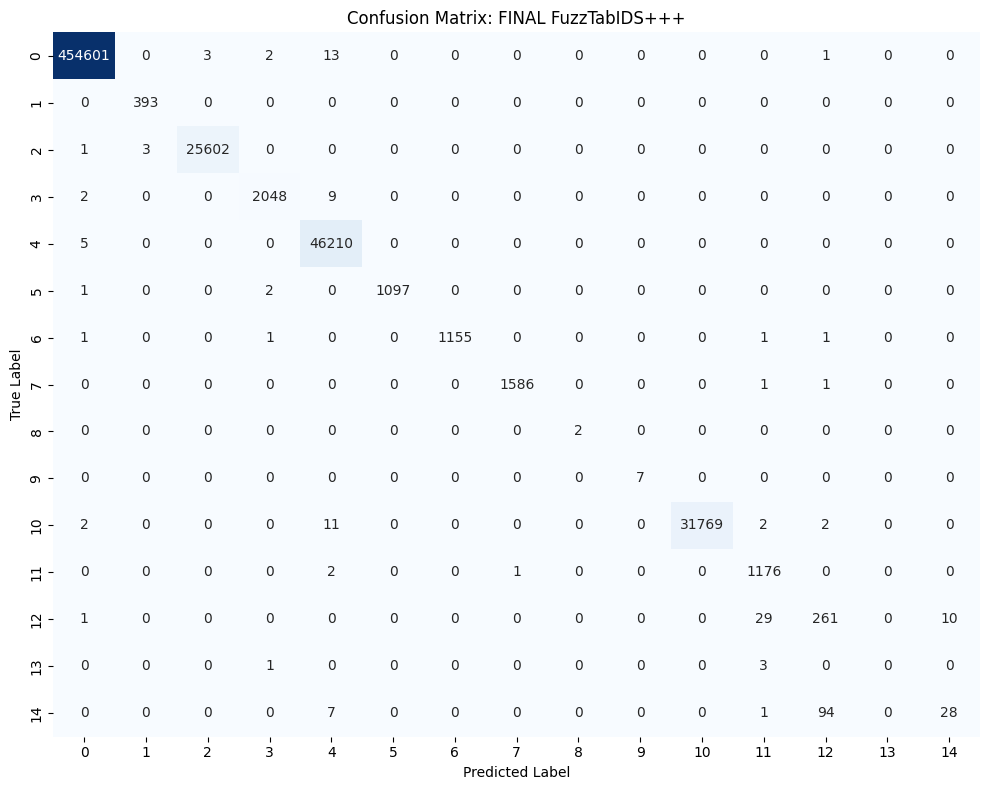

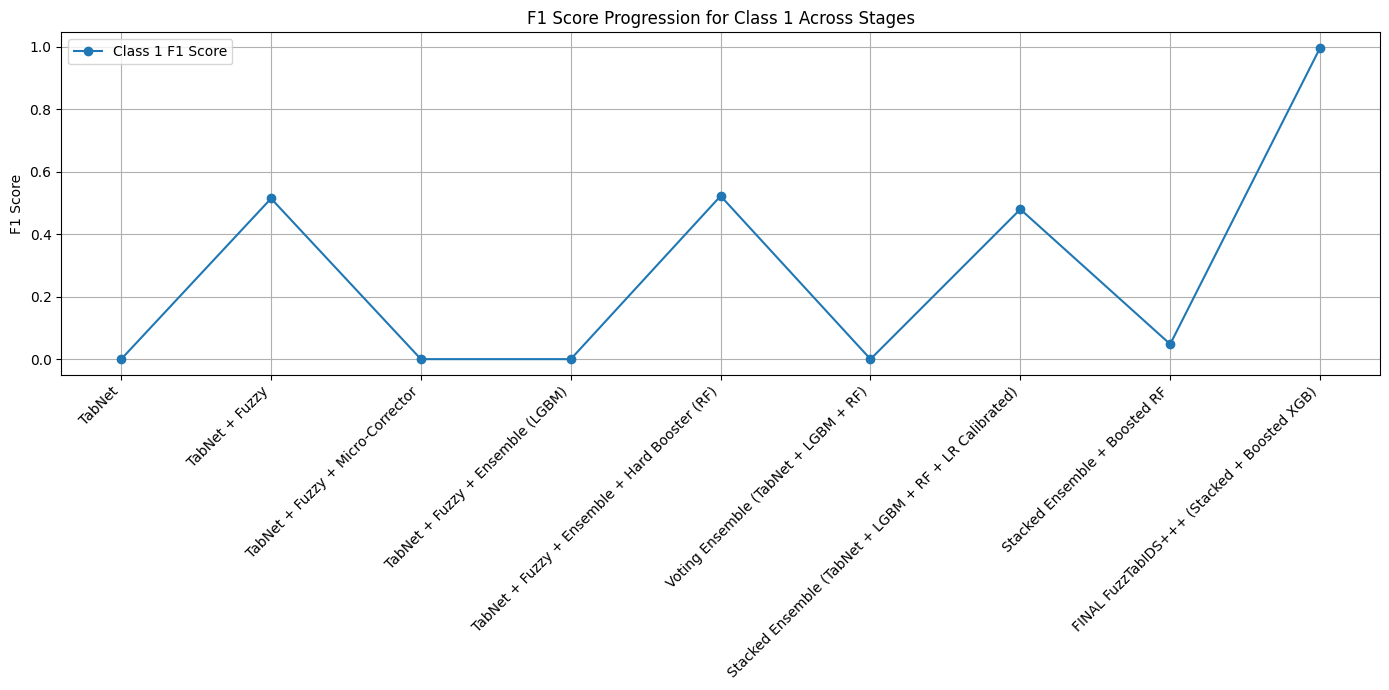

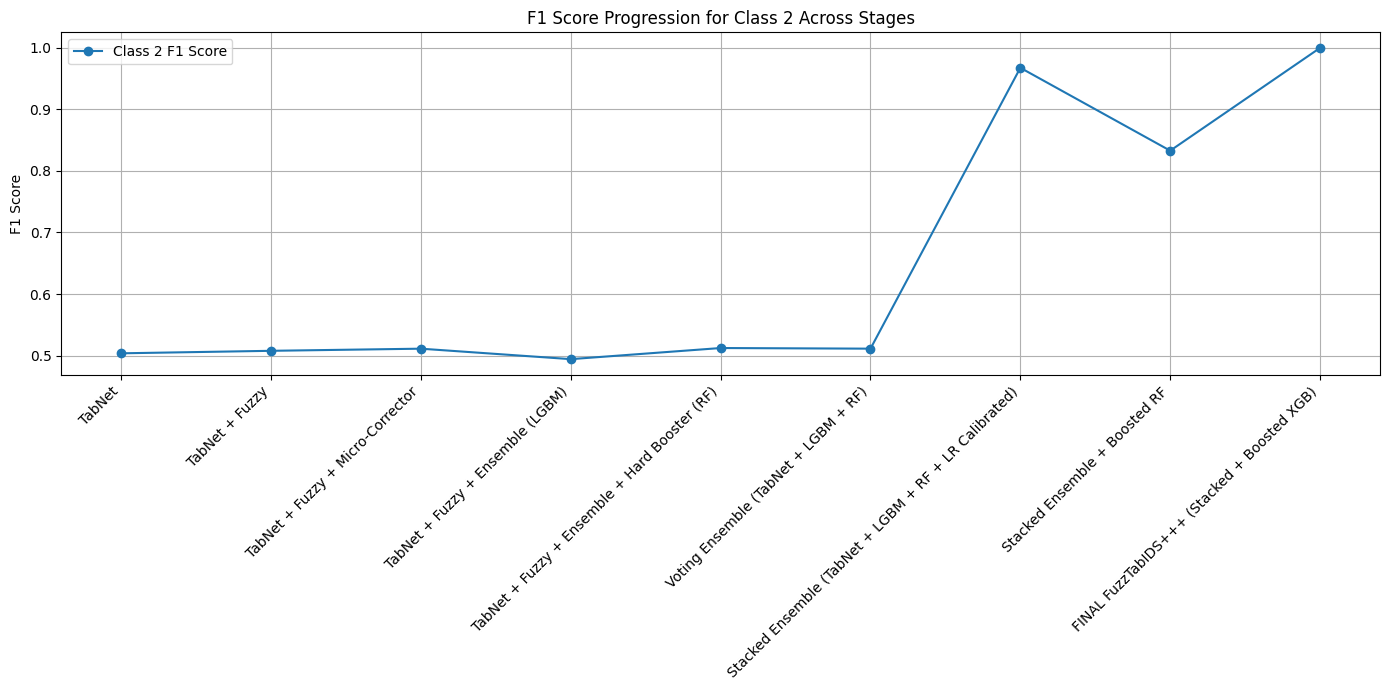

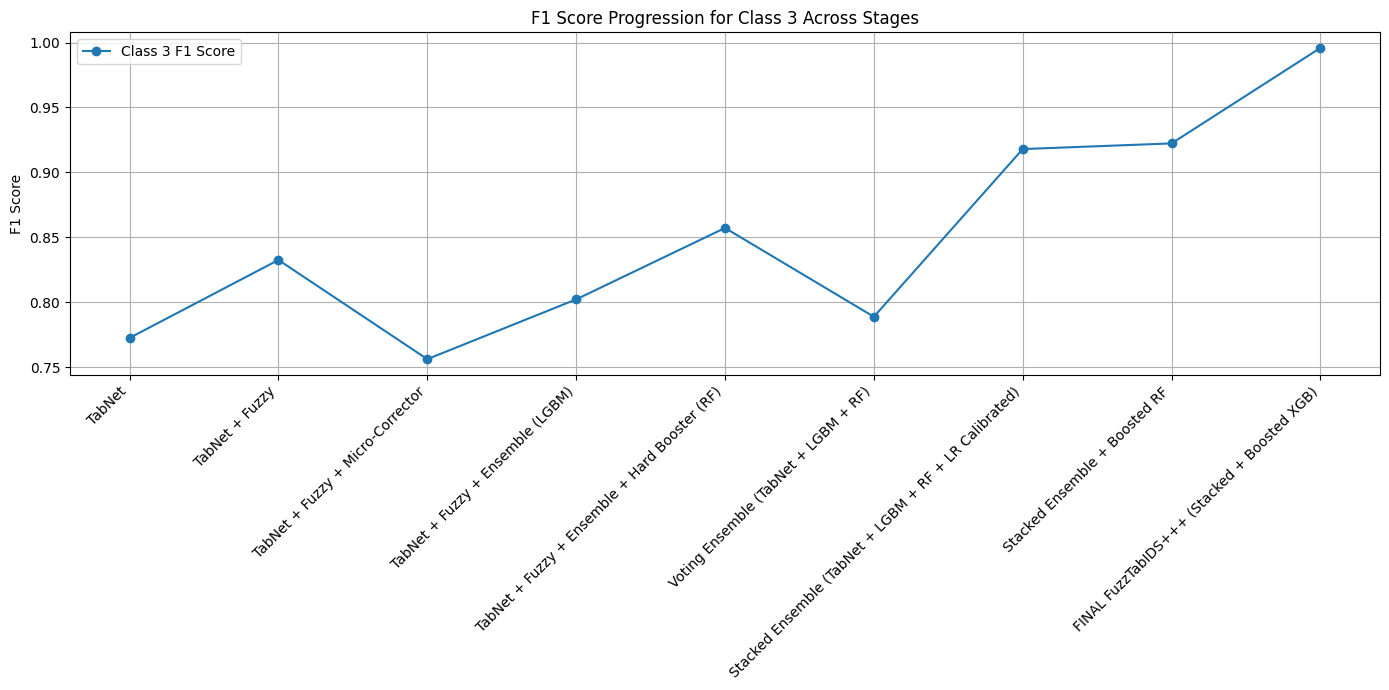

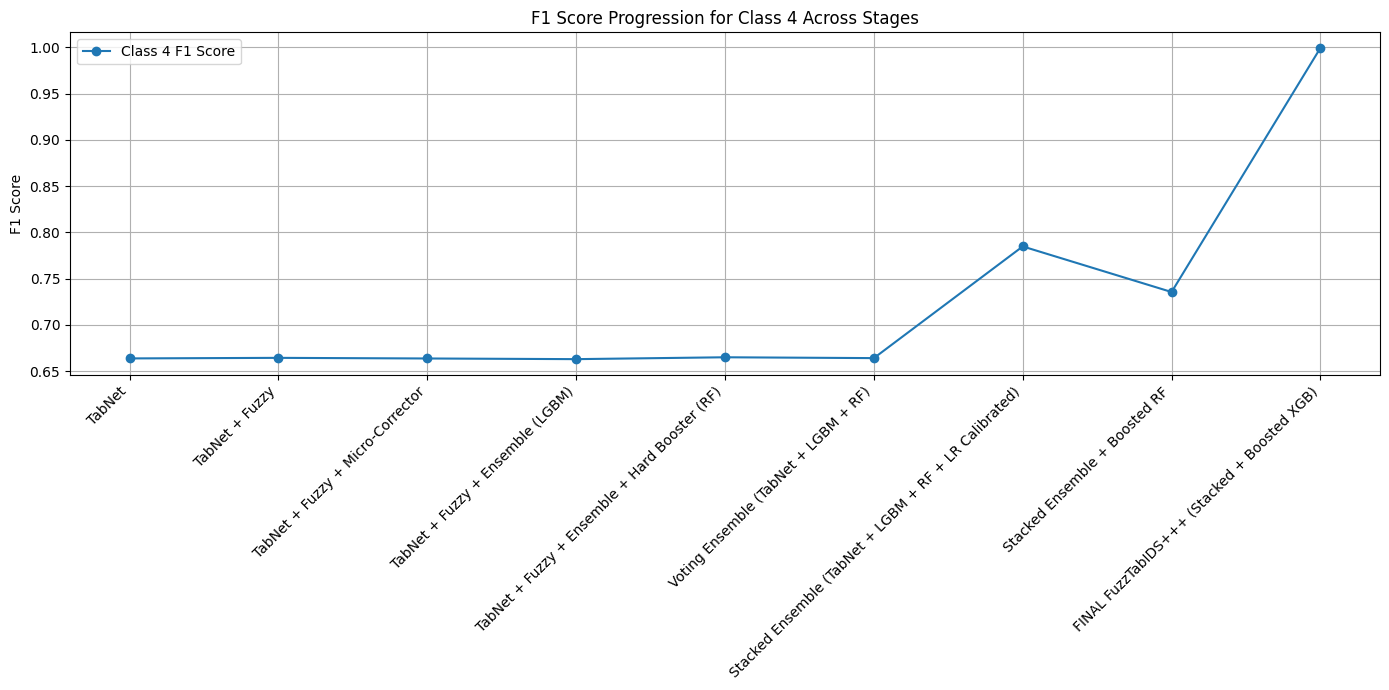

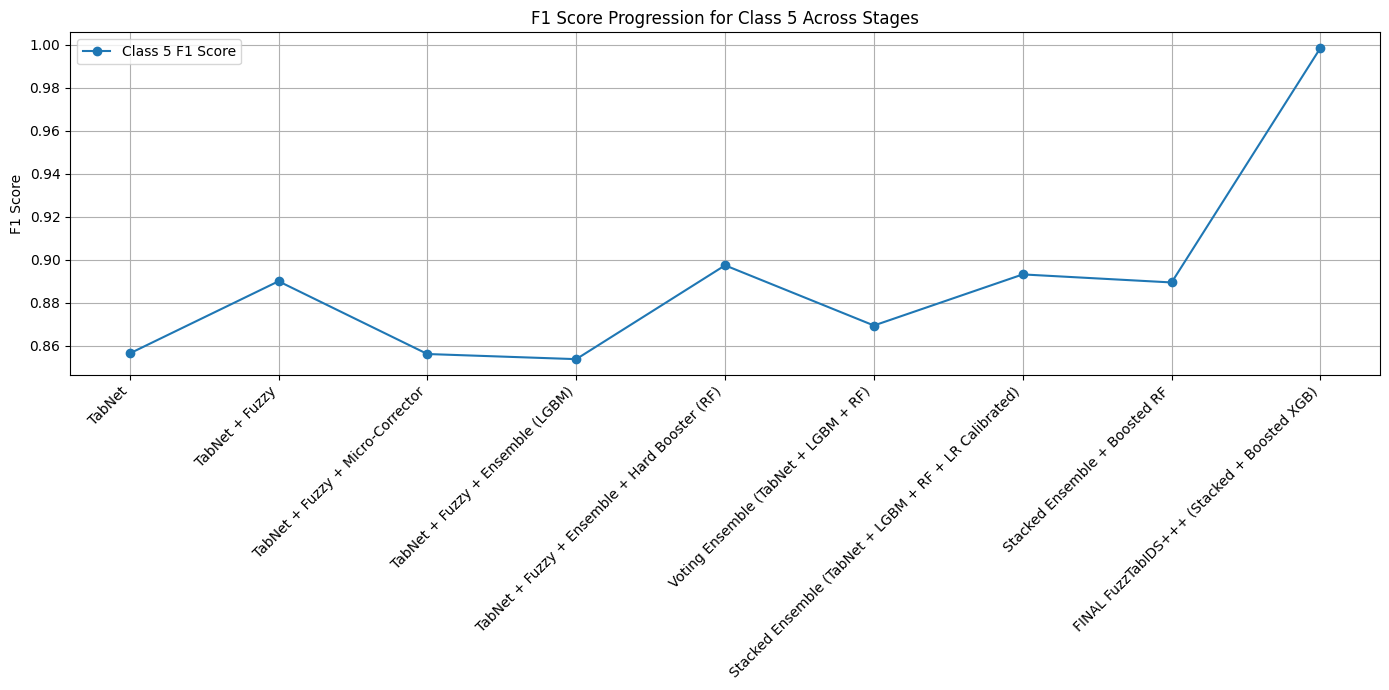

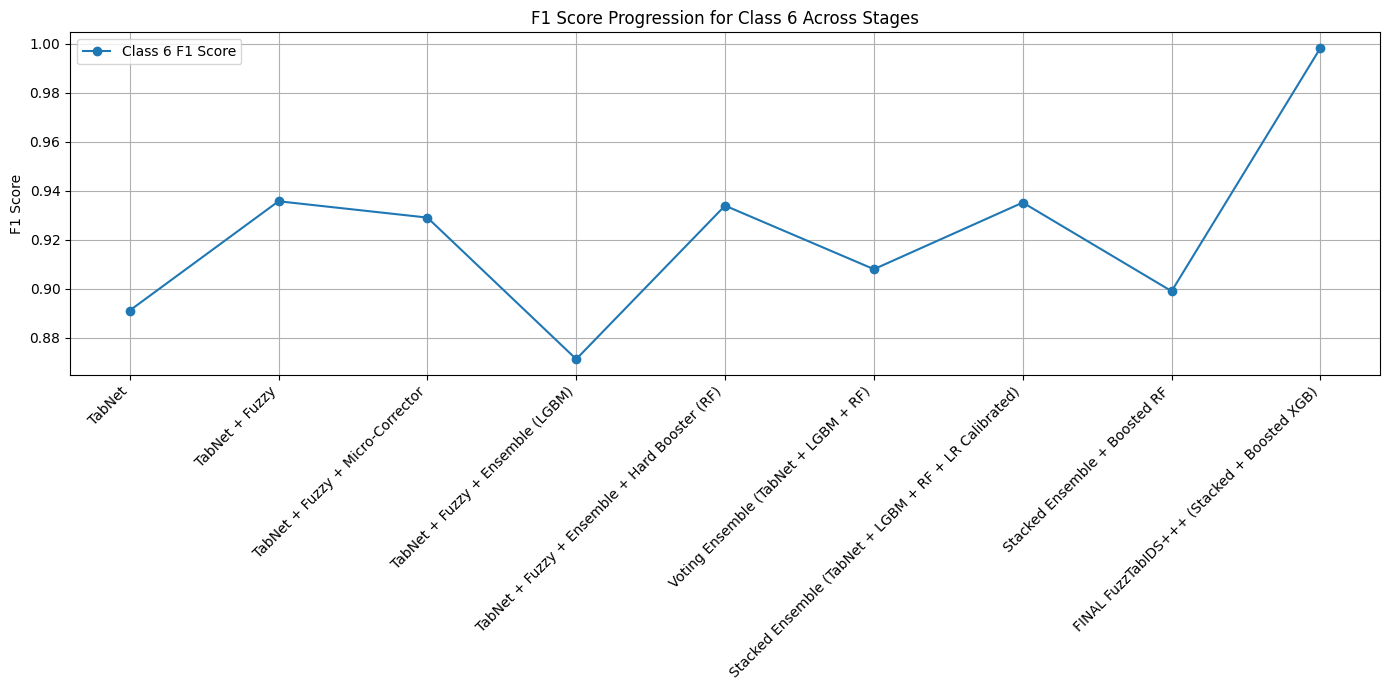

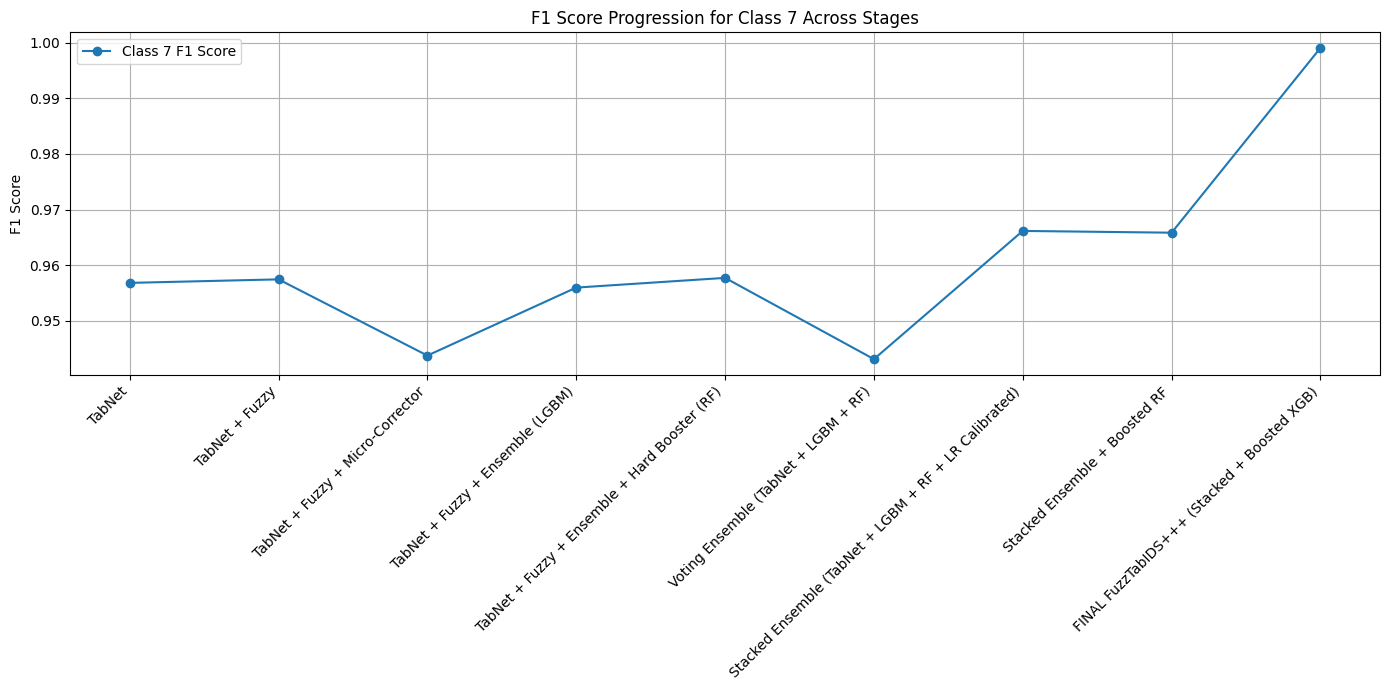

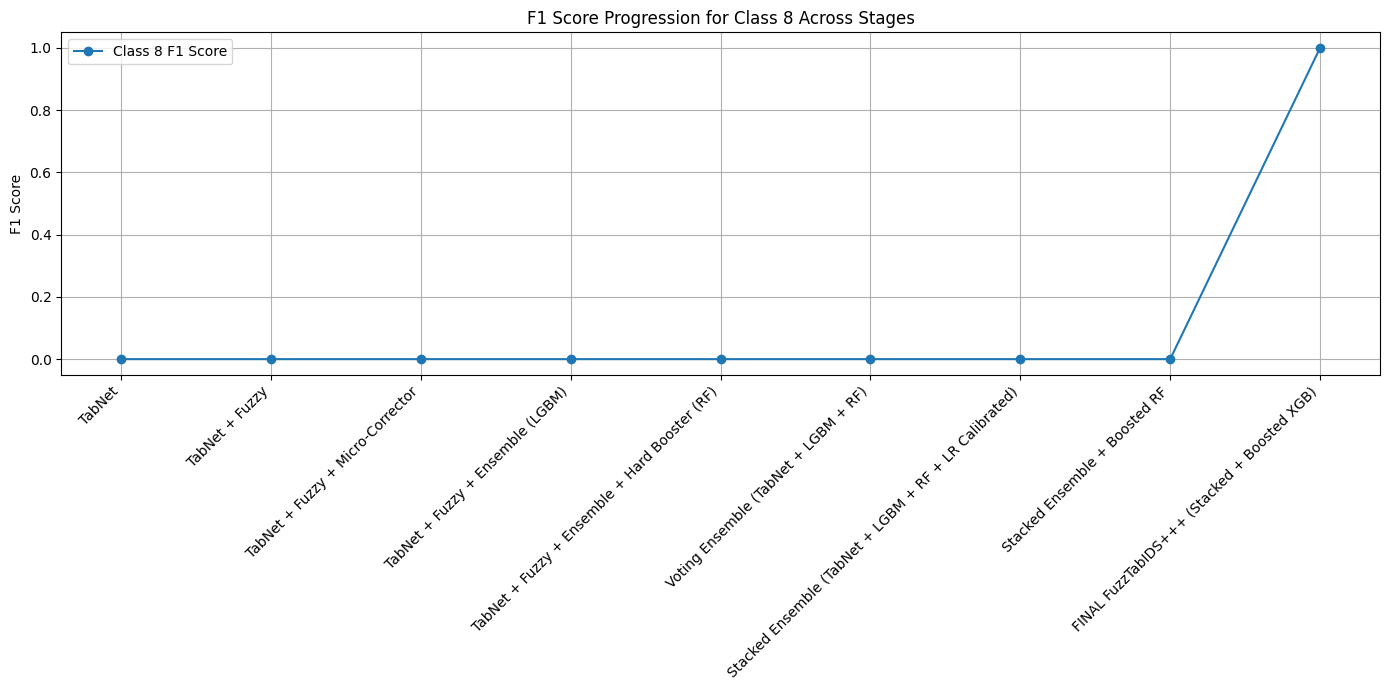

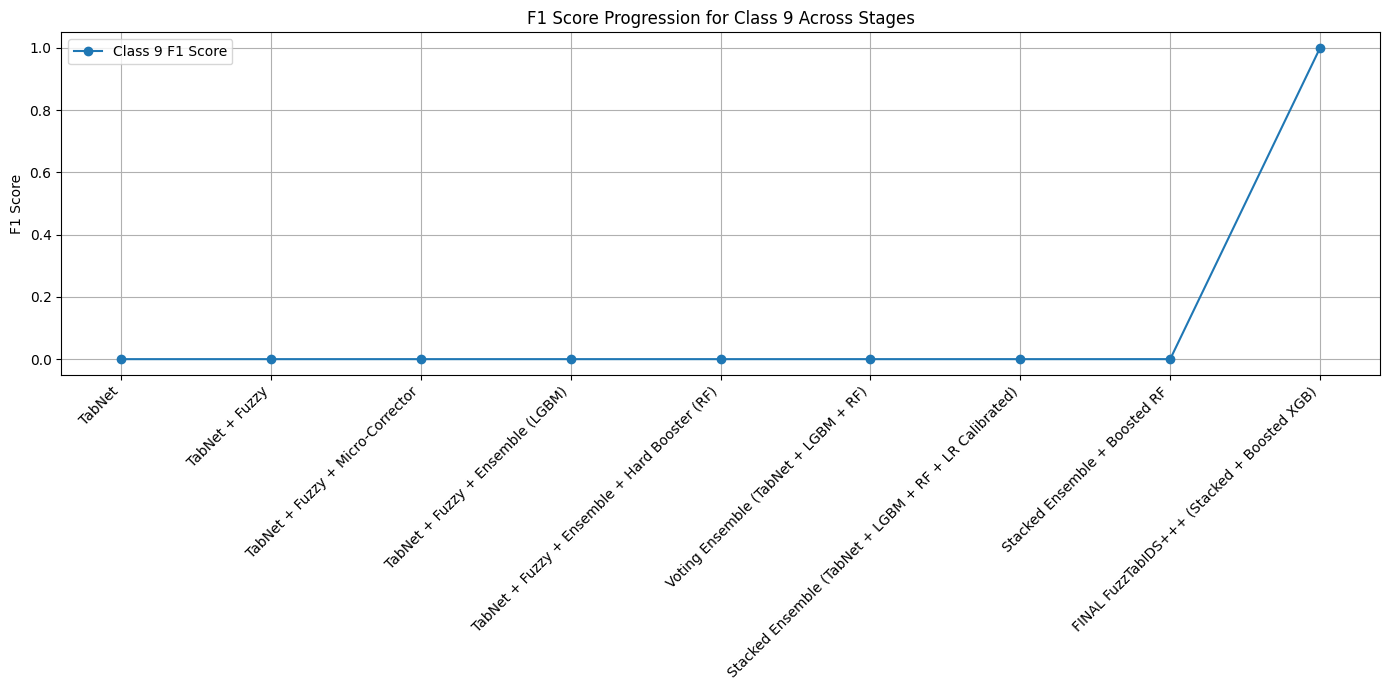

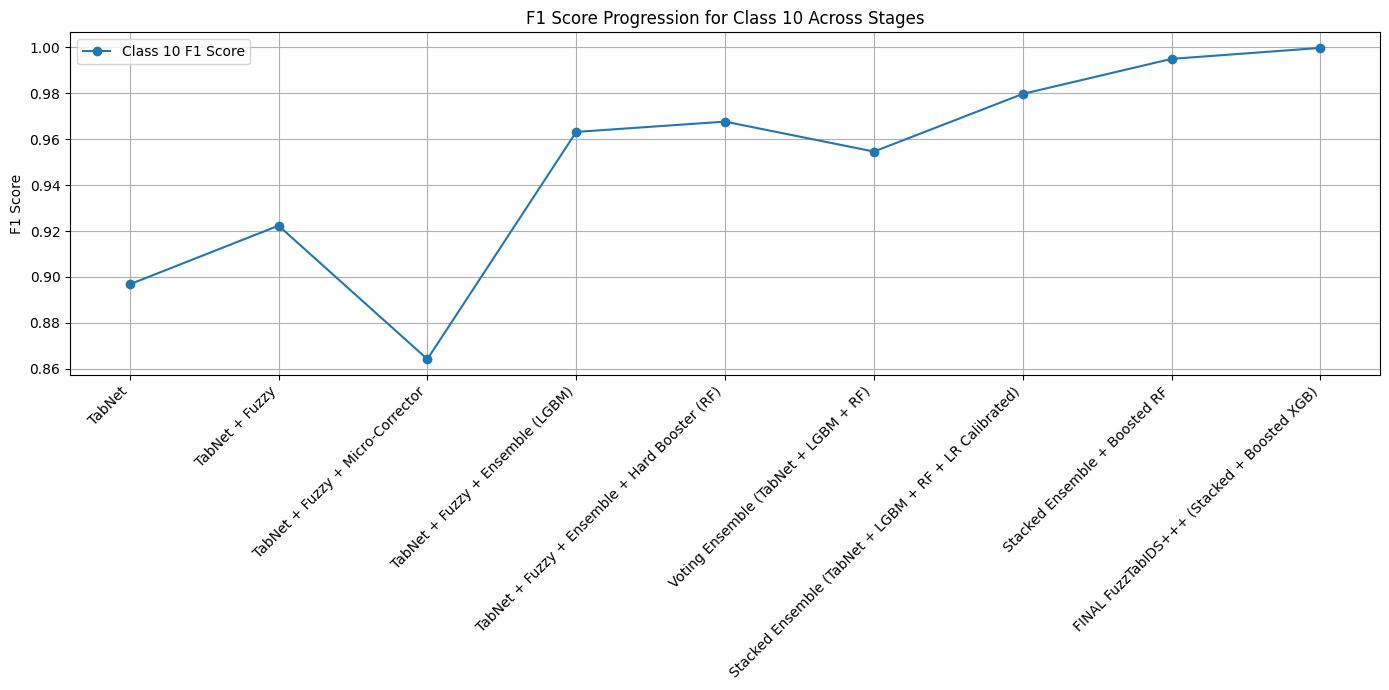

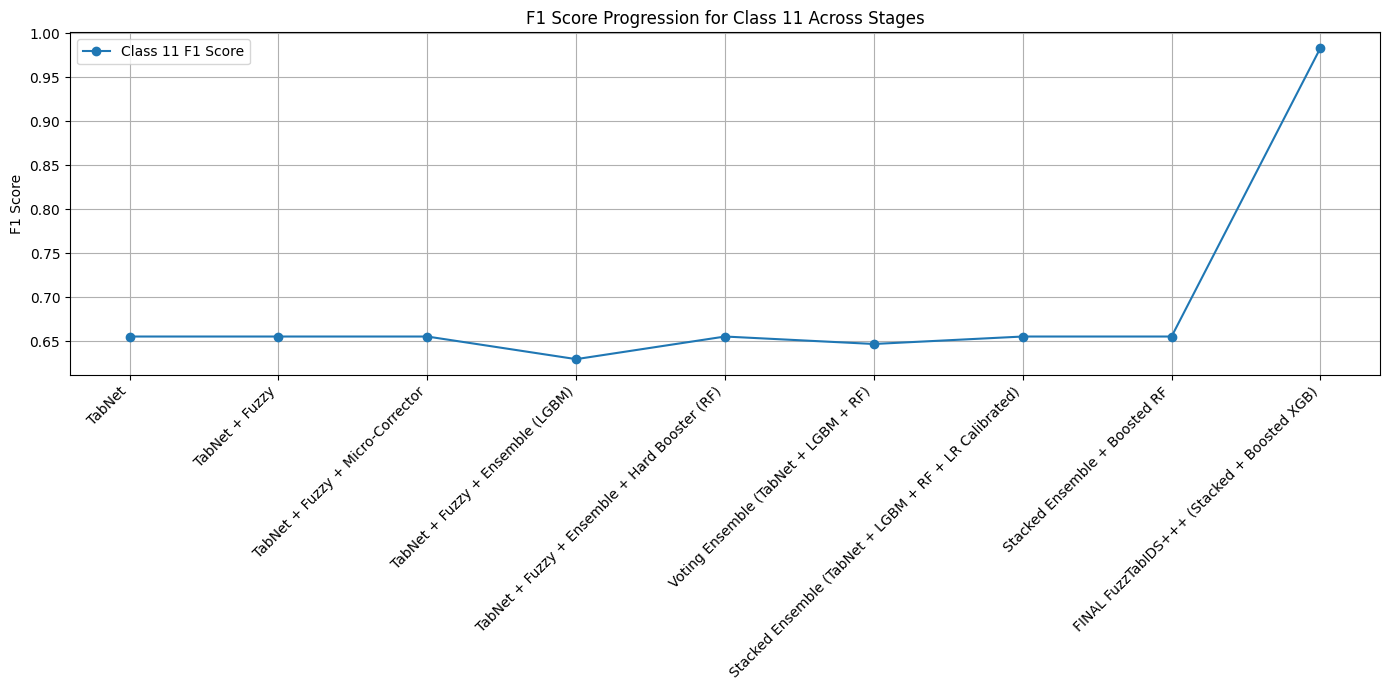

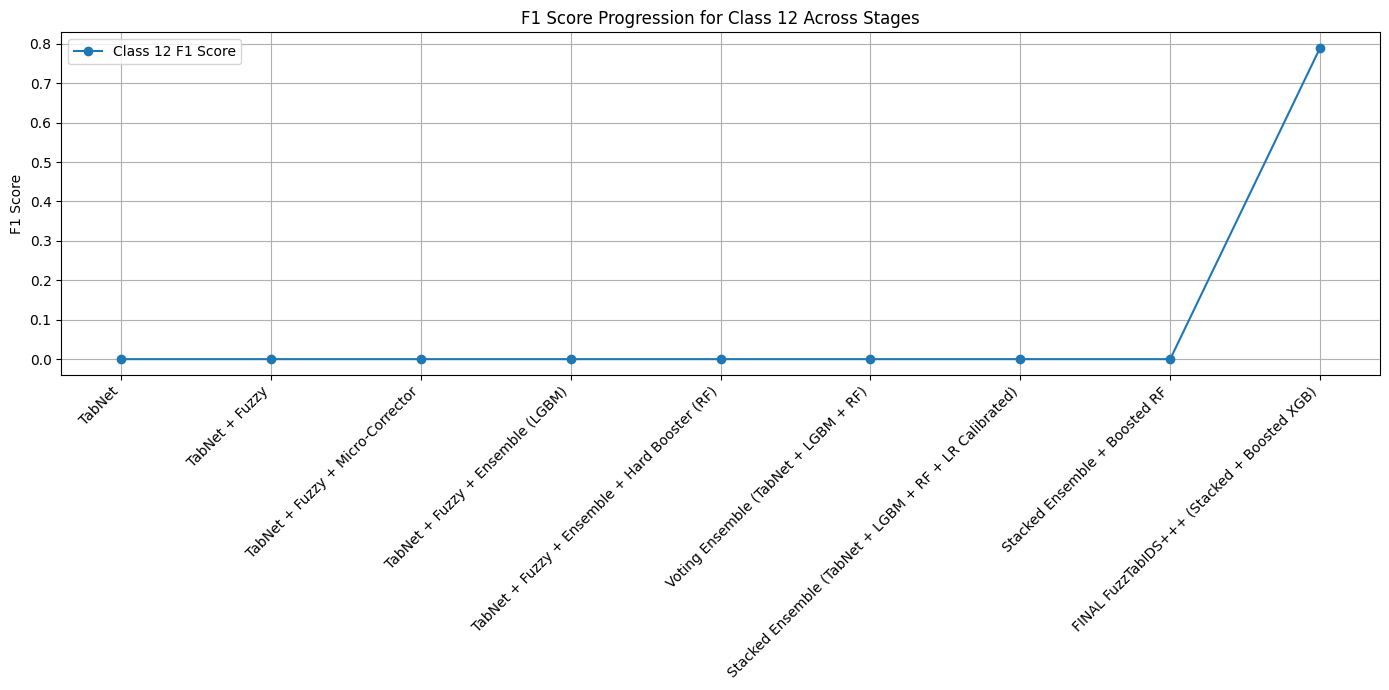

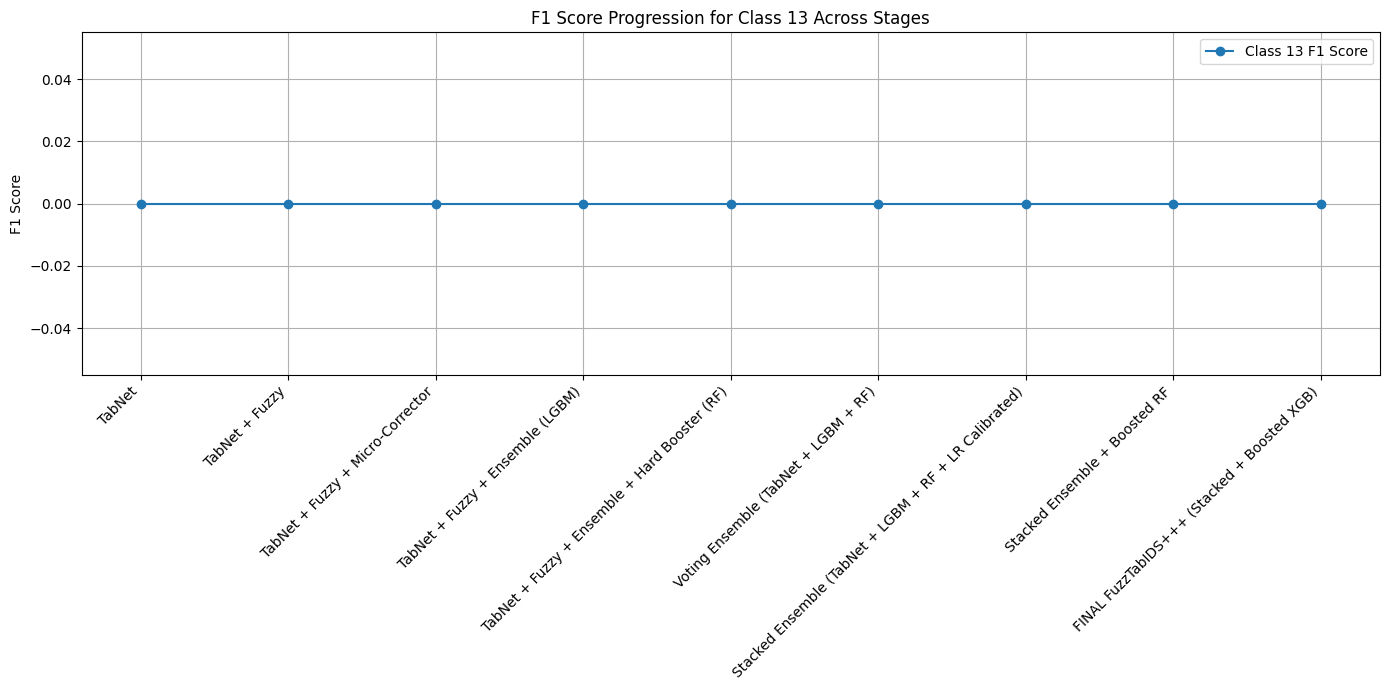

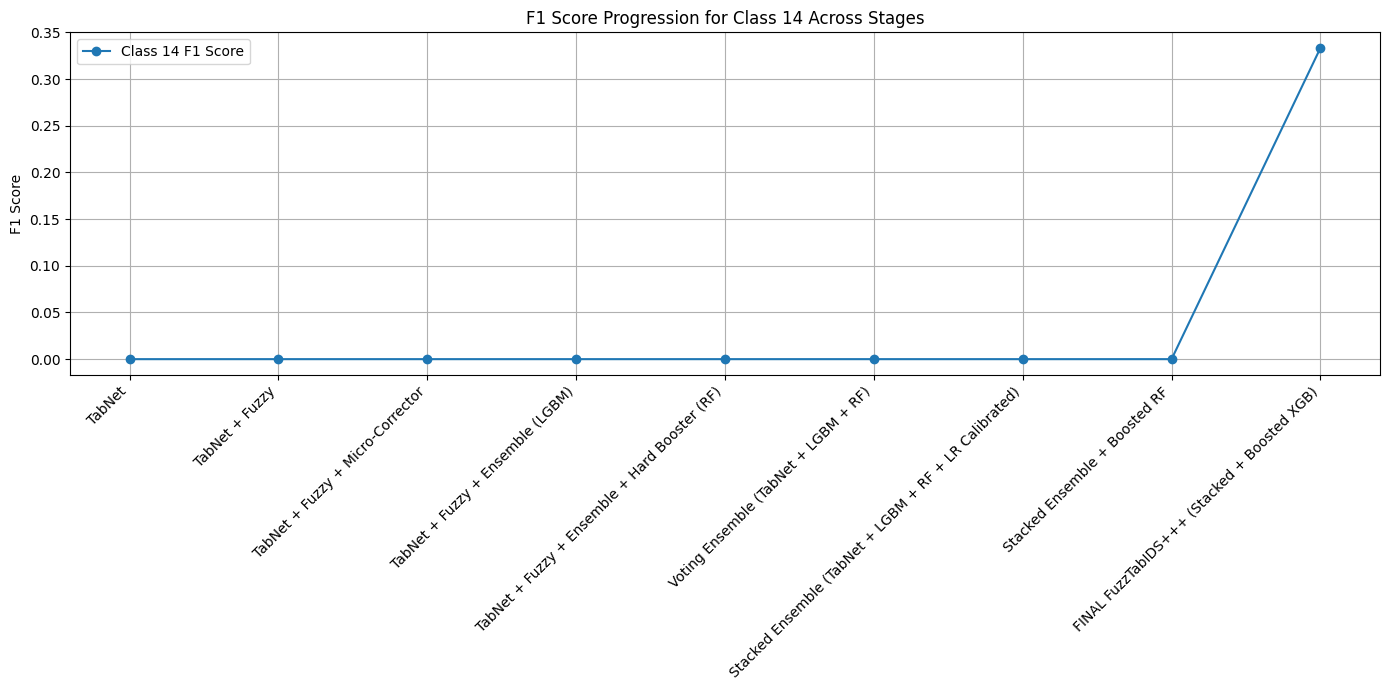

In [ ]:
# prompt: all necessary plotting showing differences

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# Combine all prediction results into a dictionary
results = {
    "TabNet": {
        "Accuracy": accuracy_score(y_test, clf.predict(X_test)),
        "F1 Score": f1_score(y_test, clf.predict(X_test), average='weighted'),
        "Report": classification_report(y_test, clf.predict(X_test), output_dict=True)
    },
    "TabNet + Fuzzy": {
        "Accuracy": accuracy_score(true_labels, fuzzy_preds),
        "F1 Score": f1_score(true_labels, fuzzy_preds, average='weighted'),
        "Report": classification_report(true_labels, fuzzy_preds, output_dict=True)
    },
    "TabNet + Fuzzy + Micro-Corrector": {
        "Accuracy": accuracy_score(y_test, y_corrected_final) if len(error_indices) > 20 else None,
        "F1 Score": f1_score(y_test, y_corrected_final, average='weighted') if len(error_indices) > 20 else None,
        "Report": classification_report(y_test, y_corrected_final, output_dict=True) if len(error_indices) > 20 else None
    },
    "TabNet + Fuzzy + Ensemble (LGBM)": {
         "Accuracy": accuracy_score(y_test, y_ensemble),
         "F1 Score": f1_score(y_test, y_ensemble, average='weighted'),
         "Report": classification_report(y_test, y_ensemble, output_dict=True)
    },
     "TabNet + Fuzzy + Ensemble + Hard Booster (RF)": {
        "Accuracy": accuracy_score(y_test, y_final_boosted) if len(hard_errors) > 20 else None,
        "F1 Score": f1_score(y_test, y_final_boosted, average='weighted') if len(hard_errors) > 20 else None,
        "Report": classification_report(y_test, y_final_boosted, output_dict=True) if len(hard_errors) > 20 else None
    },
    "Voting Ensemble (TabNet + LGBM + RF)": {
        "Accuracy": accuracy_score(y_test, y_super_final),
        "F1 Score": f1_score(y_test, y_super_final, average='weighted'),
        "Report": classification_report(y_test, y_super_final, output_dict=True)
    },
    "Stacked Ensemble (TabNet + LGBM + RF + LR Calibrated)": {
        "Accuracy": accuracy_score(y_test, y_super_calibrated),
        "F1 Score": f1_score(y_test, y_super_calibrated, average='weighted'),
        "Report": classification_report(y_test, y_super_calibrated, output_dict=True)
    },
    "Stacked Ensemble + Boosted RF": {
        "Accuracy": accuracy_score(y_test, y_99x),
        "F1 Score": f1_score(y_test, y_99x, average='weighted'),
        "Report": classification_report(y_test, y_99x, output_dict=True)
    },
     "FINAL FuzzTabIDS+++ (Stacked + Boosted XGB)": {
        "Accuracy": accuracy_score(y_test, y_ultra),
        "F1 Score": f1_score(y_test, y_ultra, average='weighted'),
        "Report": classification_report(y_test, y_ultra, output_dict=True)
    }
}

# --- Plotting Metrics ---

metrics = ['Accuracy', 'F1 Score']
model_names = list(results.keys())
accuracy_scores = [results[model]['Accuracy'] for model in model_names if results[model]['Accuracy'] is not None]
f1_scores = [results[model]['F1 Score'] for model in model_names if results[model]['F1 Score'] is not None]
model_names_filtered = [model for model in model_names if results[model]['Accuracy'] is not None] # Filter names for plotting


x = np.arange(len(model_names_filtered)) # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score (Weighted)')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Performance Across Stages')
ax.set_xticks(x)
ax.set_xticklabels(model_names_filtered, rotation=45, ha="right")
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.4f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

# --- Plotting Confusion Matrices for key stages ---

key_stages_preds = {
    "TabNet Base": clf.predict(X_test),
    "TabNet + Fuzzy": fuzzy_preds,
    "FINAL FuzzTabIDS+++": y_ultra
}

for stage_name, predictions in key_stages_preds.items():
    # Get unique labels from both true and predicted for the current stage
    all_labels = np.unique(np.concatenate([y_test, predictions]))
    cm = confusion_matrix(y_test, predictions, labels=all_labels)
    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=all_labels,
                yticklabels=all_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {stage_name}")
    plt.tight_layout()
    plt.show()

# --- Plotting Precision/Recall/F1 for Class 1 (Attack) ---

# Assuming class 1 is 'Bot' based on the label encoding map, but let's dynamically get it
# Find the class label for 'Bot' from the label_map
# Note: label_map is not directly available in this cell, assuming it's a global variable or can be accessed.
# For robustness, let's iterate through all classes except the majority class (BENIGN, which is 0)
# and plot their F1 scores.

# Get all unique labels present in the test set
present_labels = np.unique(y_test)
# Exclude the majority class (assuming 0 is BENIGN)
attack_labels = [label for label in present_labels if label != 0]


metrics_class_attack = ['precision', 'recall', 'f1-score']
precision_scores_attack = {metric: [] for metric in attack_labels}
recall_scores_attack = {metric: [] for metric in attack_labels}
f1_scores_attack = {metric: [] for metric in attack_labels}
model_names_for_metrics = []

for model_name, result in results.items():
    if result['Report'] is not None:
        report = result['Report']
        model_names_for_metrics.append(model_name)
        for label in attack_labels:
             # Ensure the label exists in the report keys before accessing
            if str(label) in report:
                precision_scores_attack[label].append(report[str(label)]['precision'])
                recall_scores_attack[label].append(report[str(label)]['recall'])
                f1_scores_attack[label].append(report[str(label)]['f1-score'])
            else:
                # Append NaN or 0 if the class is not in the report for this model
                precision_scores_attack[label].append(np.nan)
                recall_scores_attack[label].append(np.nan)
                f1_scores_attack[label].append(np.nan)


# Plotting F1 scores for each attack class across models
for label in attack_labels:
    plt.figure(figsize=(14, 7))
    plt.plot(model_names_for_metrics, f1_scores_attack[label], marker='o', linestyle='-', label=f'Class {label} F1 Score')
    plt.ylabel('F1 Score')
    plt.title(f'F1 Score Progression for Class {label} Across Stages')
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

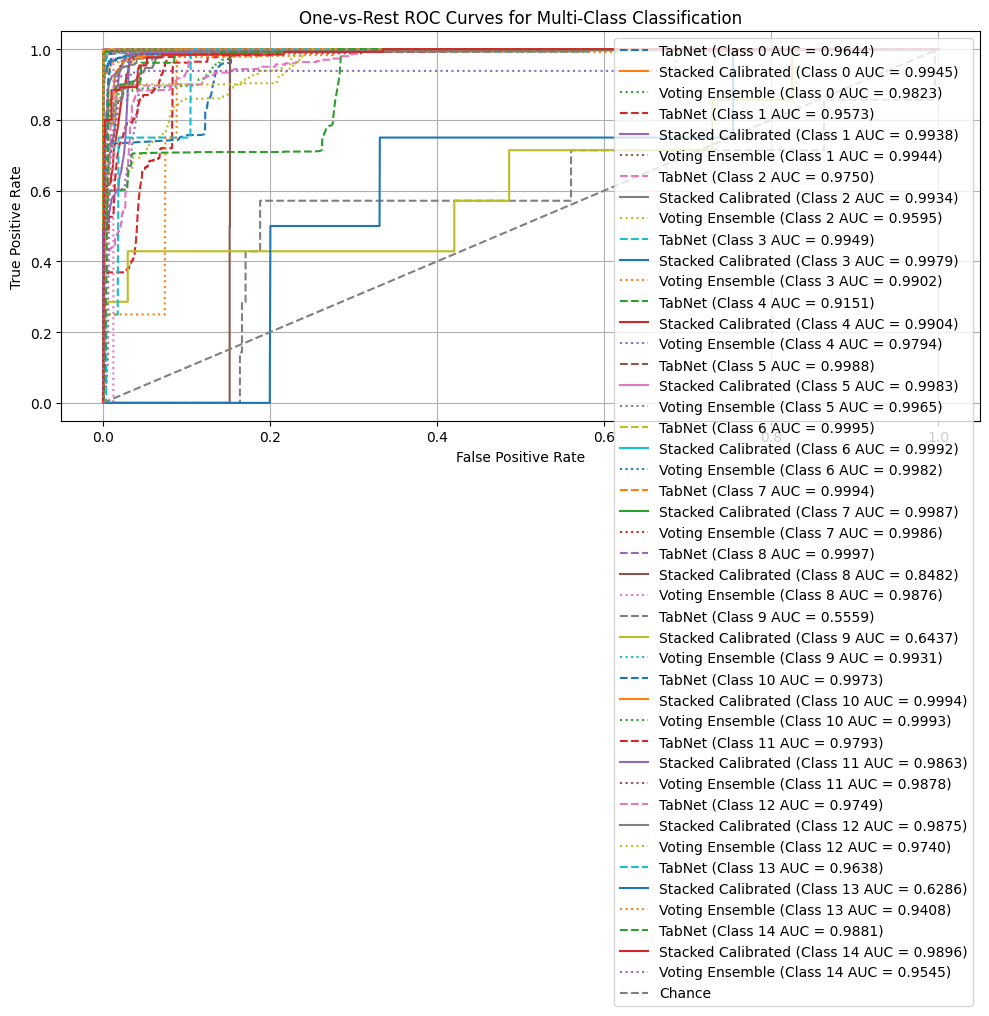

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'clf' is your initial TabNet model and 'meta_model' is your final calibrated model
# Get unique class labels from the test set
classes = np.unique(y_test)

# Binarize the true labels for OvR plotting
y_test_bin = label_binarize(y_test, classes=classes)

# Get probabilities from key models
tabnet_probs = clf.predict_proba(X_test)
# Need probabilities from the final stacked calibrated model
# Assuming 'meta_model' is the Logistic Regression calibrator trained on stacked features
# And stacked_inputs were the features used for meta_model training
y_super_calibrated_probs = meta_model.predict_proba(stacked_inputs)

# Get probabilities from the voting ensemble (from cell jnNMM0am6O8N)
# Assuming ensemble_probs is still available or can be recomputed
# Recompute ensemble_probs if necessary (based on weights from cell jnNMM0am6O8N)
# Assuming tabnet_probs, lgbm_probs, and rf_probs are available from previous cells
ensemble_probs = (
    0.5 * tabnet_probs +
    0.3 * lgbm_probs +
    0.2 * rf_probs
)


plt.figure(figsize=(10, 8))

# Plot OvR ROC for each class
for i in range(len(classes)):
    fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_bin[:, i], tabnet_probs[:, i])
    fpr_calibrated, tpr_calibrated, _ = roc_curve(y_test_bin[:, i], y_super_calibrated_probs[:, i])
    fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test_bin[:, i], ensemble_probs[:, i])

    plt.plot(fpr_tabnet, tpr_tabnet, label=f"TabNet (Class {classes[i]} AUC = {auc(fpr_tabnet, tpr_tabnet):.4f})", linestyle='--')
    plt.plot(fpr_calibrated, tpr_calibrated, label=f"Stacked Calibrated (Class {classes[i]} AUC = {auc(fpr_calibrated, tpr_calibrated):.4f})", linestyle='-')
    plt.plot(fpr_ensemble, tpr_ensemble, label=f"Voting Ensemble (Class {classes[i]} AUC = {auc(fpr_ensemble, tpr_ensemble):.4f})", linestyle=':')


plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves for Multi-Class Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

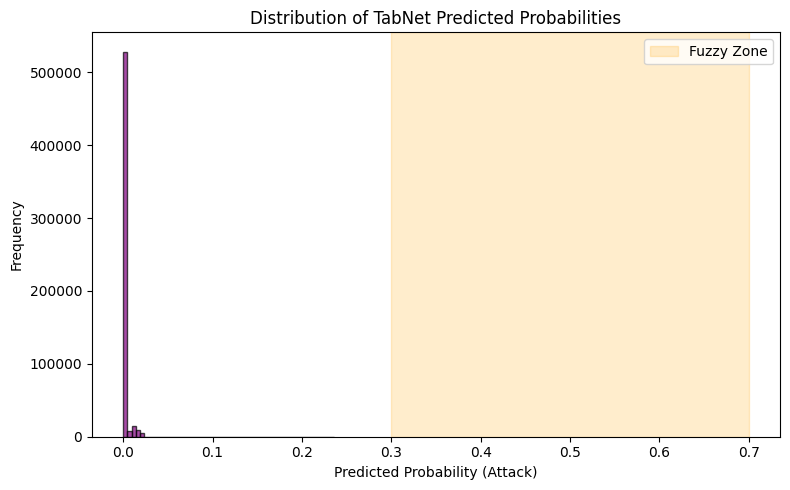

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_proba[:, 1], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.axvspan(0.3, 0.7, color='orange', alpha=0.2, label='Fuzzy Zone')
plt.title("Distribution of TabNet Predicted Probabilities")
plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
